# Automated Bridge Crack Detection: U-Net Segmentation

This notebook implements the deep learning segmentation model.
- Encoder-Decoder U-Net for 448x448 images
- Combined BCE + Dice Loss to handle ~1.5% crack imbalance
- Robust PyTorch Dataset and augmentations with `albumentations`

In [1]:
!pip install albumentations segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [2]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"Using device: {device}")

Using device: cuda


## 1. Extract Dataset & Define Loaders

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/bridge_crack_detection/dataset_split.zip'
EXTRACT_DIR = '/content/data'
DATA_DIR = os.path.join(EXTRACT_DIR, 'dataset_split')

if os.path.exists(ZIP_PATH):
    print(f"Extracting {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

if not os.path.exists(DATA_DIR) and os.path.exists(os.path.join(EXTRACT_DIR, 'train')):
    DATA_DIR = EXTRACT_DIR

print(f"Using DATA_DIR: {DATA_DIR}")
if os.path.exists(DATA_DIR):
    print("Contents of DATA_DIR:", os.listdir(DATA_DIR))

class CrackDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
        mask = np.expand_dims(mask, axis=-1).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def get_paired_files(split_name):
    base = os.path.join(DATA_DIR, split_name)
    img_paths = sorted(glob.glob(os.path.join(base, 'images', '*.*')))
    mask_paths = sorted(glob.glob(os.path.join(base, 'masks', '*.*')))
    return img_paths, mask_paths

if os.path.exists(DATA_DIR):
    t_i, t_m = get_paired_files('train')
    v_i, v_m = get_paired_files('val')
    test_i, test_m = get_paired_files('test')

    print(f"Found {len(t_i)} training images, {len(v_i)} validation images, {len(test_i)} test images.")

    if len(t_i) > 0:
        TRAIN_LOADER = DataLoader(CrackDataset(t_i, t_m, train_transform), batch_size=8, shuffle=True)
        VAL_LOADER = DataLoader(CrackDataset(v_i, v_m, val_test_transform), batch_size=8, shuffle=False)
        TEST_LOADER = DataLoader(CrackDataset(test_i, test_m, val_test_transform), batch_size=8, shuffle=False)
    else:
        print("Warning: No training images found. Please check your folder structure within DATA_DIR.")
else:
    print("Error: DATA_DIR does not exist!")

Mounted at /content/drive
Extracting /content/drive/MyDrive/bridge_crack_detection/dataset_split.zip...
Using DATA_DIR: /content/data
Contents of DATA_DIR: ['val', 'train', 'test']
Found 220 training images, 47 validation images, 48 test images.


## 2. U-Net Architecture Implementation

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        in_ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(in_ch, f))
            in_ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.up_transposes = nn.ModuleList()
        self.decoder = nn.ModuleList()
        for f in reversed(features):
            self.up_transposes.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.encoder:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(len(self.up_transposes)):
            x = self.up_transposes[idx](x)
            x = self.decoder[idx](torch.cat((skips[idx], x), dim=1))

        return self.final_conv(x)

## 3. Loss & Training

In [5]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce_loss(logits, targets)
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        intersection = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
        dice_loss = 1.0 - ((2.0 * intersection + smooth) / (union + smooth)).mean()
        return (self.bce_weight * bce) + ((1.0 - self.bce_weight) * dice_loss)

def calc_metrics(probs, targets, threshold=0.5):
    preds = (probs > threshold).float()
    tp = (preds * targets).sum()
    positives = preds.sum()
    true_y = targets.sum()
    union = positives + true_y - tp

    r = (tp + 1e-6) / (true_y + 1e-6)
    p = (tp + 1e-6) / (positives + 1e-6)
    iou = (tp + 1e-6) / (union + 1e-6)
    dice = (2 * tp + 1e-6) / (positives + true_y + 1e-6)
    return r.item(), p.item(), dice.item(), iou.item()

if os.path.exists(DATA_DIR) and 'TRAIN_LOADER' in locals():
    unet_model = UNet().to(device)
    criterion = BCEDiceLoss(bce_weight=0.5)
    optimizer = optim.Adam(unet_model.parameters(), lr=1e-4)
    best_val_loss = float('inf')

    epochs = 25
    for epoch in range(epochs):
        unet_model.train()
        train_loss = 0.0
        for imgs, masks in tqdm(TRAIN_LOADER, desc=f"Epoch {epoch+1}"):
            imgs, masks = imgs.to(device), masks.to(device)
            masks = masks.permute(0, 3, 1, 2)  # Fix shape mismatch [B, H, W, C] -> [B, C, H, W]

            optimizer.zero_grad()
            outputs = unet_model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        unet_model.eval()
        val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in VAL_LOADER:
                imgs, masks = imgs.to(device), masks.to(device)
                masks = masks.permute(0, 3, 1, 2)  # Fix shape mismatch [B, H, W, C] -> [B, C, H, W]

                outputs = unet_model(imgs)
                val_loss += criterion(outputs, masks).item()
                _, _, d, i = calc_metrics(torch.sigmoid(outputs), masks)
                val_dice += d; val_iou += i

        avg_val_loss = val_loss / len(VAL_LOADER)
        print(f"Train Loss: {train_loss/len(TRAIN_LOADER):.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {val_dice/len(VAL_LOADER):.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(unet_model.state_dict(), "best_unet.pth")

Epoch 1:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.7567 | Val Loss: 0.7360 | Val Dice: 0.0182


Epoch 2:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.6652 | Val Loss: 0.6468 | Val Dice: 0.2155


Epoch 3:   0%|          | 0/28 [00:00<?, ?it/s]

...

Train Loss: 0.4722 | Val Loss: 0.4665 | Val Dice: 0.6974


Epoch 24:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.4644 | Val Loss: 0.4573 | Val Dice: 0.6999


Epoch 25:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.4555 | Val Loss: 0.4494 | Val Dice: 0.6983


## 4. Test Evaluation & Visualization

Testing:   0%|          | 0/6 [00:00<?, ?it/s]


Mean Recall:    0.8226
Mean Precision: 0.5862
Mean Dice/F1:   0.6812
Mean IoU:       0.5244


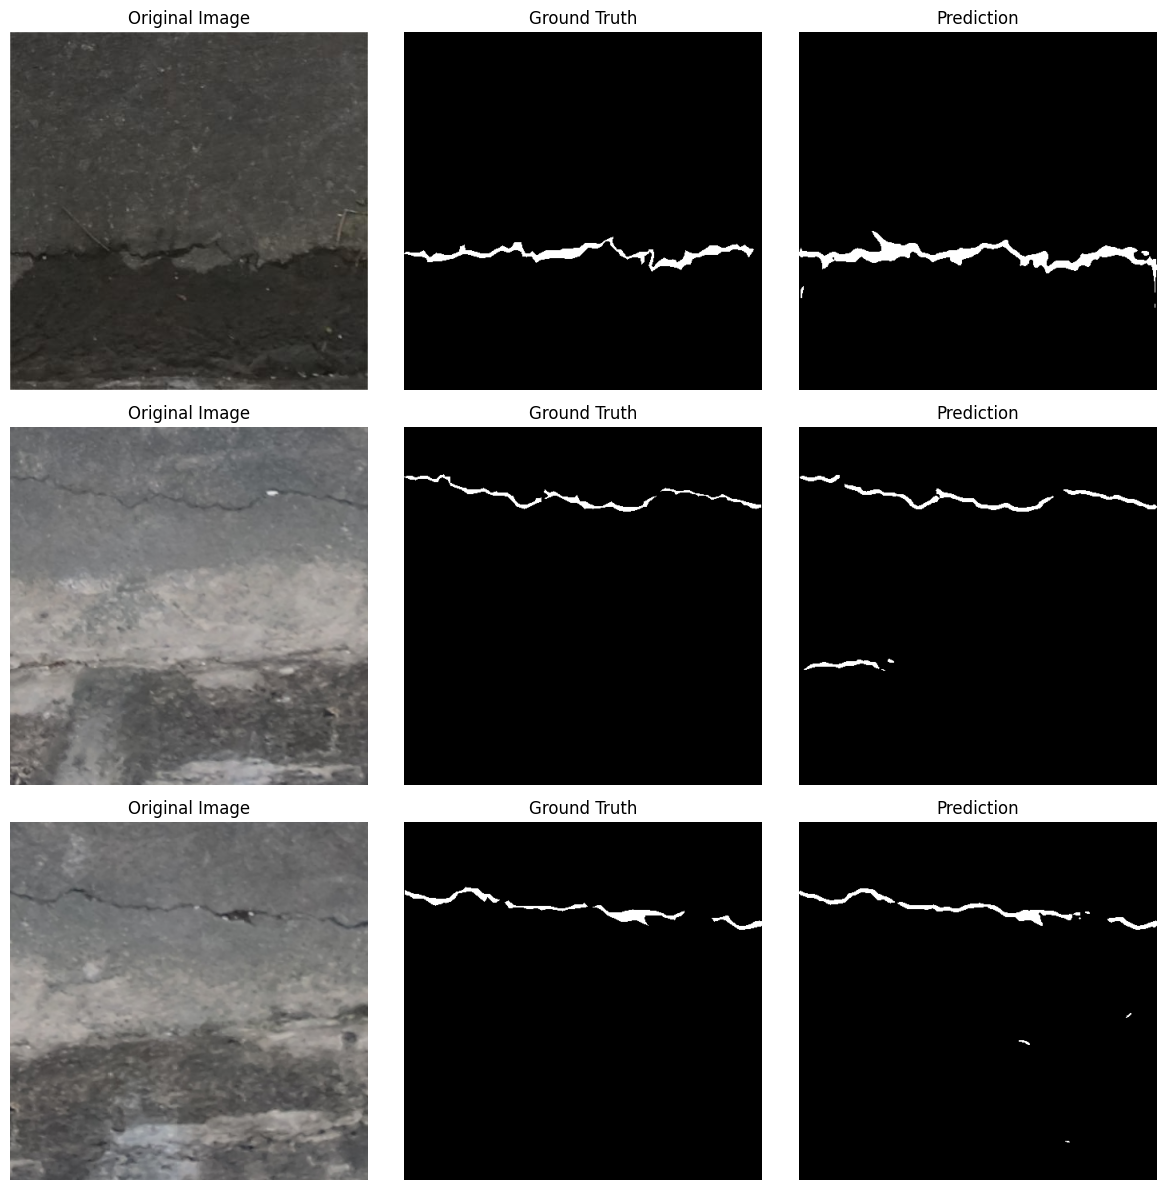

In [15]:
if os.path.exists(DATA_DIR) and os.path.exists("best_unet.pth"):
    unet_model = UNet().to(device)
    unet_model.load_state_dict(torch.load("best_unet.pth"))
    unet_model.eval()

    test_rec, test_prec, test_dice, test_iou = 0.0, 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(TEST_LOADER, desc="Testing"):
            imgs, masks = imgs.to(device), masks.to(device)
            masks = masks.permute(0, 3, 1, 2)  # FIX: Permute masks to match output shape

            outputs = unet_model(imgs)
            r, p, d, i = calc_metrics(torch.sigmoid(outputs), masks)
            test_rec += r; test_prec += p; test_dice += d; test_iou += i

    print(f"\nMean Recall:    {test_rec / len(TEST_LOADER):.4f}")
    print(f"Mean Precision: {test_prec / len(TEST_LOADER):.4f}")
    print(f"Mean Dice/F1:   {test_dice / len(TEST_LOADER):.4f}")
    print(f"Mean IoU:       {test_iou / len(TEST_LOADER):.4f}")

    # Visualize one batch
    imgs, masks = next(iter(TEST_LOADER))
    masks = masks.permute(0, 3, 1, 2)
    with torch.no_grad():
        preds = (torch.sigmoid(unet_model(imgs.to(device))) > 0.5).float().cpu().numpy()

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i in range(min(3, len(imgs))):
        img_vis = imgs[i].permute(1, 2, 0).numpy()
        img_vis = (img_vis * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)

        axes[i, 0].imshow(img_vis); axes[i, 0].set_title("Original Image"); axes[i, 0].axis('off')
        axes[i, 1].imshow(masks[i].squeeze().numpy(), cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
        axes[i, 2].imshow(preds[i].squeeze(), cmap='gray'); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
from sklearn.metrics import classification_report
import torch

# 1. Initialize lists to store results
all_preds = []
all_labels = []

unet_model.eval()
with torch.no_grad():
    for images, labels in TEST_LOADER:
        images, labels = images.to(device), labels.to(device)
        labels = labels.permute(0, 3, 1, 2)  # Consistency with model output

        outputs = unet_model(images)

        # Convert outputs to discrete class predictions
        # For binary classification with out_channels=1, using sigmoid and threshold
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

# 2. Generate report
report = classification_report(all_labels, all_preds, target_names=['No Crack', 'Crack'])

print("=== Segmentation Test Report ===")
print(report)

=== Segmentation Test Report ===
              precision    recall  f1-score   support

    No Crack       1.00      0.99      1.00   9508839
       Crack       0.60      0.83      0.70    124953

    accuracy                           0.99   9633792
   macro avg       0.80      0.91      0.85   9633792
weighted avg       0.99      0.99      0.99   9633792

